# F12 — Predicción vs realidad: 3 días seguidos (XGBoost del núcleo)

Este notebook **no vuelve a definir el modelo**: ejecuta `F11_ML_nucleo.ipynb` tal cual
(hasta la celda donde queda listo `pred_xgb`) y reutiliza sus objetos en memoria:

| objeto | qué es |
|---|---|
| `pred_xgb` | predicciones del representante XGBoost, formato ancho `fecha_objetivo x price_h00..price_h23` |
| `P` | precio real, mismo formato ancho |
| `df`, `X_train`, `y_train`, `feature_cols` | matriz y features del F11, para reentrenar variantes |
| `errores`, `evaluar_dinero`, `ingreso_arbitraje`, `pivotear_pred` | funciones del F11 |
| `BASELINES` | baselines (`persistencia_d1`, etc.) para contexto |

Dos partes:

1. **Modelo completo** (§4-5): curva horaria de **72 horas seguidas** (3 días naturales
   consecutivos) con precio real vs predicho, panel día a día y métricas diarias.
2. **Modelo sin las columnas de precio de mercado del día D** (§6): mismo entrenamiento, mismas
   semillas, mismos días y mismos gráficos, quitando `es_esios_D`, los cinco precios ENTSO-E
   (`pt`, `fr`, `de_lu`, `it_nord`, `pl`) y los tres `spread_es_*_D`.

> Ejecución: ~2-3 min (entrenamiento del F11 más las 3 semillas de la variante reducida).


## 0. Configuración

In [1]:
from pathlib import Path

# Ruta al notebook que entrena el modelo. Si queda en None se busca automáticamente.
RUTA_F11 = "C:/Users/Powan/Desktop/Maestria/TFM/edev_models/modelos/ML_Magui/F11_ML_nucleo.ipynb"

# Primer día de los tres a dibujar. None = los tres últimos días consecutivos disponibles.
# Ejemplo: FECHA_INICIO = "2025-11-18"
FECHA_INICIO = None

N_DIAS = 3                     # días consecutivos a comparar
MODELO = "XGBoost"             # "XGBoost" o "LightGBM"
MOSTRAR_BASELINE = True        # dibuja persistencia_d1 como referencia gris
GUARDAR_PNG = True

COLOR_REAL = "#2b2b2b"
COLOR_PRED = "#e8622c"         # modelo completo
COLOR_SIN = "#3987e5"          # modelo sin precios del día D
COLOR_BASE = "#a8a6a0"

print("Configuración lista.")

Configuración lista.


## 1. Localizar y ejecutar `F11_ML_nucleo.ipynb`

Se ejecutan sus celdas de código en este mismo espacio de nombres y se **para en cuanto existen
`pred_xgb` y `P`** — así se salta toda la sección de gráficos del F11, que aquí no hace falta.

Dos protecciones sobre el notebook original, ninguna modifica el fichero en disco:

1. **Sintaxis.** La celda de carga del F11 tiene pegado un `BlockingIOError` suelto detrás de
   `GOLD / "matriz_nucleo.csv"` (`ruta_csv = GOLD / "matriz_nucleo.csv"BlockingIOError`), que
   revienta la compilación. Se limpia en memoria y se avisa por pantalla.
2. **Escritura.** La celda de entrenamiento del F11 guarda la tabla por semilla en
   `GOLD / "matriz_nucleo.csv"`, es decir, **encima del propio dataset de entrada**. Aquí se
   bloquea ese `to_csv` concreto durante la ejecución para no destruir la matriz.


In [2]:
import os, re, sys, contextlib
from pathlib import Path

import nbformat


def localizar_f11(ruta=None) -> Path:
    if ruta:
        p = Path(ruta).expanduser().resolve()
        if not p.is_file():
            raise FileNotFoundError(f"No existe: {p}")
        return p
    candidatos = []
    base = Path.cwd().resolve()
    for carpeta in [base, *base.parents][:5]:
        candidatos += [carpeta / "F11_ML_nucleo.ipynb",
                       carpeta / "modelos" / "F11_ML_nucleo.ipynb",
                       carpeta / "notebooks" / "F11_ML_nucleo.ipynb"]
    for p in candidatos:
        if p.is_file():
            return p.resolve()
    raise FileNotFoundError(
        "No encuentro F11_ML_nucleo.ipynb. Indica la ruta a mano en RUTA_F11.")


def limpiar(src: str) -> str:
    """Quita magics/shell y el token suelto que rompe la celda de carga del F11."""
    limpio = re.sub(r'(?<=[\"\'])BlockingIOError\b', "", src)
    if limpio != src:
        print("  aviso: se ha limpiado un 'BlockingIOError' suelto en el código del F11.")
    return "\n".join(l for l in limpio.splitlines()
                      if not l.lstrip().startswith(("%", "!")))


@contextlib.contextmanager
def proteger_csv(nombres=("matriz_nucleo.csv",)):
    """Impide que el F11 sobrescriba el dataset de entrada al ejecutar su to_csv."""
    import pandas as pd
    original = pd.DataFrame.to_csv

    def to_csv_protegido(self, path_or_buf=None, *a, **k):
        if isinstance(path_or_buf, (str, Path)) and Path(path_or_buf).name in nombres:
            print(f"  bloqueada escritura sobre {Path(path_or_buf).name} (dataset de entrada).")
            return None
        return original(self, path_or_buf, *a, **k)

    pd.DataFrame.to_csv = to_csv_protegido
    try:
        yield
    finally:
        pd.DataFrame.to_csv = original


def ejecutar_f11(ruta: Path, hasta=("pred_xgb", "pred_lgb", "P"), ns=None) -> dict:
    ns = ns if ns is not None else globals()
    nb = nbformat.read(ruta, as_version=4)
    cwd_previo = Path.cwd()
    print(f"Ejecutando {ruta} ...")
    try:
        with proteger_csv():
            for i, celda in enumerate(nb.cells):
                if celda.cell_type != "code":
                    continue
                codigo = limpiar(celda.source)
                if not codigo.strip():
                    continue
                exec(compile(codigo, f"<F11 celda {i}>", "exec"), ns)
                if all(k in ns for k in hasta):
                    print(f"\nObjetos disponibles tras la celda {i}: {', '.join(hasta)}")
                    break
            else:
                raise RuntimeError(f"El F11 terminó sin definir {hasta}")
    finally:
        os.chdir(cwd_previo)
    return ns


RUTA_F11 = localizar_f11(RUTA_F11)
ejecutar_f11(RUTA_F11)

Ejecutando C:\Users\Powan\Desktop\Maestria\TFM\edev_models\modelos\ML_Magui\F11_ML_nucleo.ipynb ...
cwd: C:\Users\Powan\Desktop\Maestria\TFM\edev_models\modelos
Constantes cargadas.
Funciones de evaluación listas.
  aviso: se ha limpiado un 'BlockingIOError' suelto en el código del F11.
57521 filas x 133 columnas -- nulos: 0
127 columnas de features
split
train         43699
validation     8759
test           5063
Name: count, dtype: int64
P (precio ancho): (2397, 24)
5 baselines: ['persistencia_d1', 'persistencia_semanal', 'perfil_4_semanas', 'media_movil_7d', 'plano_d1']
XGBoost    s42  MAE val  13.27  test  13.69   captura val  94.5%  test  94.7%
XGBoost    s43  MAE val  13.39  test  13.62   captura val  94.4%  test  94.1%
XGBoost    s44  MAE val  13.37  test  14.15   captura val  94.3%  test  93.9%
LightGBM   s42  MAE val  13.21  test  13.40   captura val  94.7%  test  94.9%
LightGBM   s43  MAE val  13.16  test  13.22   captura val  94.5%  test  95.5%
LightGBM   s44  MAE val  13.21

{'__name__': '__main__',
 '__doc__': '\nNote: all executions are function-scoped as we do not assume the code below executes in an isolated kernel environment.\n',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'from pathlib import Path\n\n# Ruta al notebook que entrena el modelo. Si queda en None se busca automáticamente.\nRUTA_F11 = "C:/Users/Powan/Desktop/Maestria/TFM/edev_models/modelos/ML_Magui/F11_ML_nucleo.ipynb"\n\n# Primer día de los tres a dibujar. None = los tres últimos días consecutivos disponibles.\n# Ejemplo: FECHA_INICIO = "2025-11-18"\nFECHA_INICIO = None\n\nN_DIAS = 3                     # días consecutivos a comparar\nMODELO = "XGBoost"             # "XGBoost" o "LightGBM"\nMOSTRAR_BASELINE = True        # dibuja persistencia_d1 como referencia gris\nGUARDAR_PNG = True\n\nCOLOR_REAL = "#2b2b2b"\nCOLOR_PRED = "#e8622c"         # modelo complet

## 2. Elegir los 3 días consecutivos

In [3]:
import numpy as np
import pandas as pd

PRED = {"XGBoost": pred_xgb, "LightGBM": pred_lgb}[MODELO]

# Días con predicción y precio real completos (24 horas en ambos).
dias_ok = (PRED.dropna(how="any").index
           .intersection(P.dropna(how="any").index)
           .sort_values())
if len(dias_ok) < N_DIAS:
    raise ValueError(f"Solo hay {len(dias_ok)} días completos con predicción.")


def bloque_consecutivo(dias, inicio=None, n=3):
    dias = pd.DatetimeIndex(dias)
    if inicio is not None:
        d0 = pd.Timestamp(inicio).normalize()
        ventana = pd.date_range(d0, periods=n, freq="D")
        faltan = ventana.difference(dias)
        if len(faltan):
            raise ValueError(f"Sin predicción para: {[str(f.date()) for f in faltan]}")
        return ventana
    # Sin fecha fija: el bloque consecutivo más reciente.
    for j in range(len(dias) - 1, n - 2, -1):
        ventana = dias[j - n + 1: j + 1]
        if (ventana == pd.date_range(ventana[0], periods=n, freq="D")).all():
            return pd.DatetimeIndex(ventana)
    raise ValueError(f"No hay {n} días consecutivos completos en el índice.")


DIAS = bloque_consecutivo(dias_ok, FECHA_INICIO, N_DIAS)
etiqueta_tramo = tramo(DIAS)

print(f"Modelo: {MODELO}")
print("Días comparados:", ", ".join(d.strftime("%Y-%m-%d (%a)") for d in DIAS))
print("Tramo:", ", ".join(f"{d.date()}={t}" for d, t in etiqueta_tramo.items()))

Modelo: XGBoost
Días comparados: 2026-07-29 (Wed), 2026-07-30 (Thu), 2026-07-31 (Fri)
Tramo: 2026-07-29=test, 2026-07-30=test, 2026-07-31=test


## 3. Funciones de comparación

Se definen una vez y se reutilizan tal cual en la §6 con el modelo reducido: métricas diarias,
serie horaria continua y los dos gráficos.


In [4]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt


def a_serie_horaria(ancho: pd.DataFrame, dias: pd.DatetimeIndex, nombre: str) -> pd.Series:
    """Formato ancho (día x 24 columnas) -> serie indexada por hora real."""
    sub = ancho.loc[dias, TARGET_COLS]
    valores = sub.to_numpy().ravel()
    horas = pd.DatetimeIndex(np.concatenate(
        [pd.date_range(d, periods=24, freq="h") for d in dias]))
    return pd.Series(valores, index=horas, name=nombre)


def metricas_diarias(pred: pd.DataFrame, dias: pd.DatetimeIndex = None) -> pd.DataFrame:
    dias = DIAS if dias is None else dias
    filas = []
    for d in dias:
        r = P.loc[d, TARGET_COLS].to_numpy()
        p_ = pred.loc[d, TARGET_COLS].to_numpy()
        e = p_ - r
        ing = float(ingreso_arbitraje(pred.loc[[d]], P.loc[[d]]).iloc[0])
        techo = float(ingreso_arbitraje(P.loc[[d]], P.loc[[d]]).iloc[0])
        filas.append({
            "dia": d.strftime("%Y-%m-%d"), "dow": d.strftime("%a"),
            "tramo": etiqueta_tramo[d],
            "MAE": np.abs(e).mean(), "RMSE": np.sqrt((e ** 2).mean()),
            "sesgo": e.mean(), "err_max": np.abs(e).max(),
            "hora_peor": int(np.abs(e).argmax()), "precio_medio": r.mean(),
            "ingreso_EUR": ing, "techo_EUR": techo,
            "capturado_%": 100 * ing / techo if techo else np.nan,
        })
    return pd.DataFrame(filas).set_index("dia")


def grafico_72h(pred, metricas, etiqueta, color=None, sufijo="", dias=None):
    """Curva continua de N_DIAS x 24 h: real vs predicho, con panel de residuos."""
    dias = DIAS if dias is None else dias
    color = color or COLOR_PRED
    real_h = a_serie_horaria(P, dias, "real")
    pred_h = a_serie_horaria(pred, dias, etiqueta)
    err = pred_h - real_h

    fig, (ax, axe) = plt.subplots(
        2, 1, figsize=(13, 7), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12})

    if MOSTRAR_BASELINE:
        base_h = a_serie_horaria(BASELINES["persistencia_d1"], dias, "persistencia_d1")
        ax.plot(base_h.index, base_h.values, color=COLOR_BASE, lw=1.1, ls="--",
                label="persistencia D-1", zorder=2)
    ax.plot(real_h.index, real_h.values, color=COLOR_REAL, lw=2.2, label="precio real", zorder=4)
    ax.plot(pred_h.index, pred_h.values, color=color, lw=2.2, label=etiqueta, zorder=4)
    ax.fill_between(real_h.index, real_h.values, pred_h.values,
                    color=color, alpha=0.15, zorder=1, label="error")

    for d in dias:
        ax.axvline(d, color="grey", lw=0.8, alpha=0.5, zorder=1)
        axe.axvline(d, color="grey", lw=0.8, alpha=0.5, zorder=1)
        fila = metricas.loc[d.strftime("%Y-%m-%d")]
        ax.annotate(f"{d.strftime('%a %d-%b')}\nMAE {fila['MAE']:.1f}",
                    xy=(d + pd.Timedelta(hours=12), ax.get_ylim()[1]),
                    xytext=(0, -4), textcoords="offset points",
                    ha="center", va="top", fontsize=9, color="#555")

    ax.set_ylabel("EUR/MWh")
    ax.set_title(f"Precio spot: real vs predicho -- {etiqueta} -- "
                 f"{dias[0].date()} a {dias[-1].date()} ({len(dias)} días seguidos)",
                 loc="left", fontsize=12)
    ax.legend(frameon=False, fontsize=9, ncols=4, loc="lower left")
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    axe.bar(err.index, err.values, width=0.03,
            color=np.where(err.values >= 0, color, COLOR_BASE))
    axe.axhline(0, color="black", lw=0.8)
    axe.set_ylabel("error\n(pred - real)", fontsize=9)
    axe.grid(alpha=0.25)
    axe.spines[["top", "right"]].set_visible(False)
    axe.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    axe.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b\n%Hh"))

    fig.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.12)
    if GUARDAR_PNG:
        salida = TEMP / f"pred_vs_real{sufijo}_{dias[0].date()}_{len(dias)}d.png"
        plt.savefig(salida, dpi=150, facecolor="white")
        print("Guardado:", salida)
    plt.show()


def grafico_paneles(pred, metricas, etiqueta, color=None, sufijo="", dias=None):
    """Un subplot por día, 24 h superpuestas en su propio eje."""
    dias = DIAS if dias is None else dias
    color = color or COLOR_PRED
    fig, axes = plt.subplots(1, len(dias), figsize=(4.6 * len(dias), 4.4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax_, d in zip(axes, dias):
        horas = range(24)
        r = P.loc[d, TARGET_COLS].to_numpy()
        p_ = pred.loc[d, TARGET_COLS].to_numpy()
        if MOSTRAR_BASELINE:
            ax_.plot(horas, BASELINES["persistencia_d1"].loc[d, TARGET_COLS].to_numpy(),
                     color=COLOR_BASE, lw=1.1, ls="--", label="persistencia D-1")
        ax_.plot(horas, r, color=COLOR_REAL, lw=2.2, marker="o", ms=3, label="real")
        ax_.plot(horas, p_, color=color, lw=2.2, marker="o", ms=3, label=etiqueta)
        ax_.fill_between(horas, r, p_, color=color, alpha=0.15)

        fila = metricas.loc[d.strftime("%Y-%m-%d")]
        ax_.set_title(f"{d.strftime('%Y-%m-%d (%a)')} -- {fila['tramo']}\n"
                      f"MAE {fila['MAE']:.2f} | sesgo {fila['sesgo']:+.2f} | "
                      f"capturado {fila['capturado_%']:.1f}%", loc="left", fontsize=10)
        ax_.set_xlabel("hora")
        ax_.set_xticks(range(0, 24, 3))
        ax_.grid(alpha=0.25)
        ax_.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel("EUR/MWh")
    axes[0].legend(frameon=False, fontsize=9)
    plt.tight_layout()
    if GUARDAR_PNG:
        salida = TEMP / f"pred_vs_real_paneles{sufijo}_{dias[0].date()}.png"
        plt.savefig(salida, dpi=150, facecolor="white")
        print("Guardado:", salida)
    plt.show()


def resumen_texto(metricas, etiqueta):
    peor, mejor = metricas["MAE"].idxmax(), metricas["MAE"].idxmin()
    sesgo_medio = metricas["sesgo"].mean()
    sentido = "por encima" if sesgo_medio > 0 else "por debajo"
    print(f"[{etiqueta}]")
    print(f"  Mejor día: {mejor} (MAE {metricas.loc[mejor, 'MAE']:.2f} EUR/MWh)")
    print(f"  Peor día:  {peor} (MAE {metricas.loc[peor, 'MAE']:.2f} EUR/MWh, "
          f"fallo máximo {metricas.loc[peor, 'err_max']:.1f} en la hora "
          f"{int(metricas.loc[peor, 'hora_peor']):02d})")
    print(f"  Sesgo medio: {sesgo_medio:+.2f} EUR/MWh -- predice {sentido} del precio real.")
    print(f"  Arbitraje 4h: {metricas['ingreso_EUR'].sum():.1f} EUR de un techo de "
          f"{metricas['techo_EUR'].sum():.1f} EUR "
          f"({100 * metricas['ingreso_EUR'].sum() / metricas['techo_EUR'].sum():.1f}%).")


print("Funciones de comparación listas.")

Funciones de comparación listas.


## 4. Modelo completo — métricas de los 3 días

In [5]:
METRICAS = metricas_diarias(PRED)
print(METRICAS.round(2).to_string())
print(f"\nMedia de los {N_DIAS} días -- MAE {METRICAS['MAE'].mean():.2f} EUR/MWh | "
      f"capturado {100 * METRICAS['ingreso_EUR'].sum() / METRICAS['techo_EUR'].sum():.1f}%")

            dow tramo    MAE   RMSE  sesgo  err_max  hora_peor  precio_medio  ingreso_EUR  techo_EUR  capturado_%
dia                                                                                                              
2026-07-29  Wed  test  21.69  34.05  12.89    76.06         14        120.43       546.28     638.66        85.54
2026-07-30  Thu  test  16.55  22.63  -0.05    50.47         13        128.55       506.74     556.81        91.01
2026-07-31  Fri  test  18.57  23.67 -17.13    48.51         19        140.01       279.17     288.50        96.77

Media de los 3 días -- MAE 18.94 EUR/MWh | capturado 89.8%


### Gráfico 1 — 72 horas seguidas: real vs predicho

Guardado: C:\Users\Powan\Desktop\Maestria\TFM\edev_models\data_temp\pred_vs_real_xgboost_completo_2026-07-29_3d.png


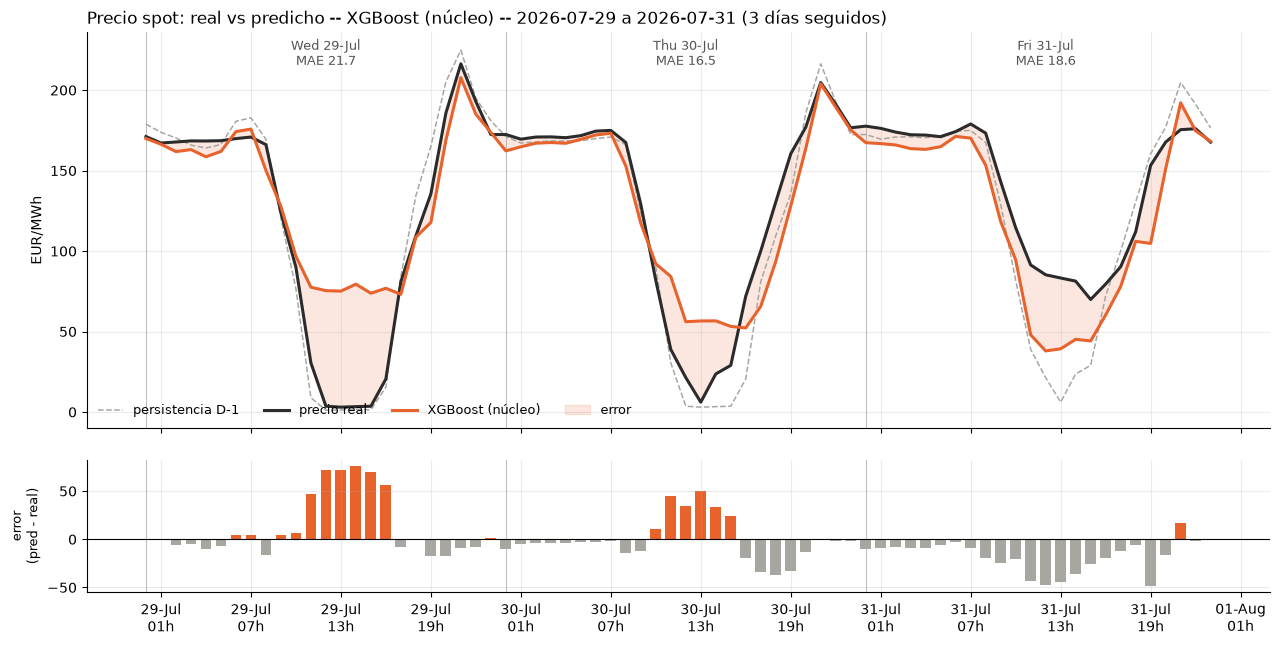

In [6]:
grafico_72h(PRED, METRICAS, f"{MODELO} (núcleo)", COLOR_PRED,
            sufijo=f"_{MODELO.lower()}_completo")

### Gráfico 2 — un panel por día

La misma información, pero con las 24 horas de cada día superpuestas en su propio eje: útil
para ver si el fallo está en el nivel (la curva entera desplazada) o en la forma (los picos de
mañana y tarde mal colocados).


Guardado: C:\Users\Powan\Desktop\Maestria\TFM\edev_models\data_temp\pred_vs_real_paneles_xgboost_completo_2026-07-29.png


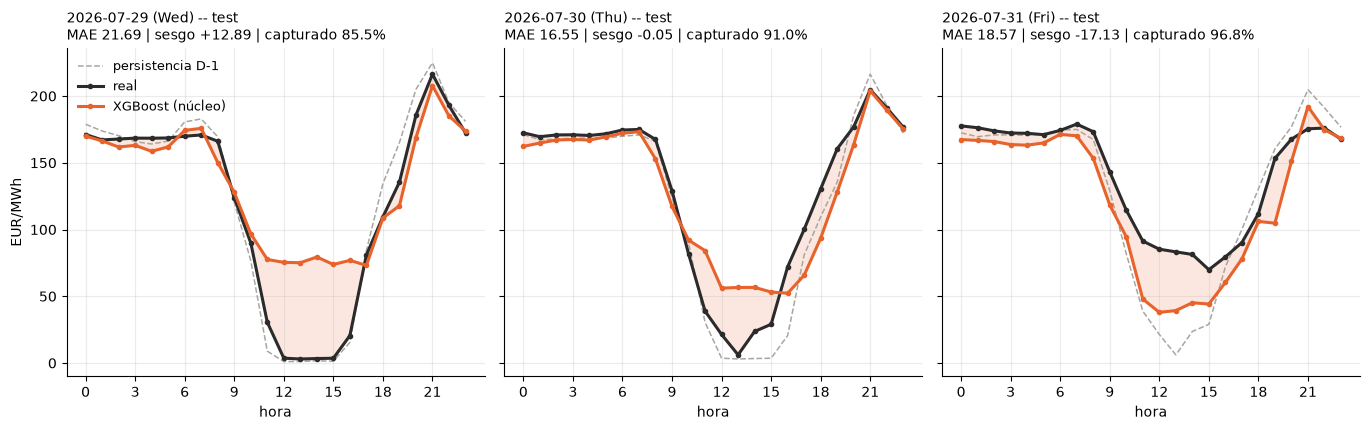

[XGBoost completo]
  Mejor día: 2026-07-30 (MAE 16.55 EUR/MWh)
  Peor día:  2026-07-29 (MAE 21.69 EUR/MWh, fallo máximo 76.1 en la hora 14)
  Sesgo medio: -1.43 EUR/MWh -- predice por debajo del precio real.
  Arbitraje 4h: 1332.2 EUR de un techo de 1484.0 EUR (89.8%).


In [7]:
grafico_paneles(PRED, METRICAS, f"{MODELO} (núcleo)", COLOR_PRED,
                sufijo=f"_{MODELO.lower()}_completo")
resumen_texto(METRICAS, f"{MODELO} completo")

In [15]:
def gain(modelo, feature_cols):
    if hasattr(modelo, "booster_"):                     # LightGBM
        v = modelo.booster_.feature_importance(importance_type="gain")
    else:                                                # XGBoost
        d = modelo.get_booster().get_score(importance_type="gain")
        v = [d.get(c, 0.0) for c in feature_cols]
    s = pd.Series(v, index=feature_cols, dtype=float)
    return (s / s.sum() * 100).sort_values(ascending=False)

In [16]:
SOSPECHOSAS = [c for c in feature_cols
               if c.endswith("_D") or c.startswith(("pdbc_", "pbfli_", "bil_"))]

g = gain(modelo, feature_cols)
print(g.head(10).round(2).to_string())
print("\n-- columnas del lado prohibido de las 11:00 --")
print(g[g.index.isin(SOSPECHOSAS)].head(10).round(2).to_string())
print(f"\nganancia total en columnas _D: {g[g.index.isin(SOSPECHOSAS)].sum():.1f} %")

pt_entsoe_D         51.00
es_esios_D          24.03
es_esios_Dm1         5.94
es_esios_Dm6         4.12
ree_gwind_prev       2.13
ree_grenov_prev      1.91
gas_ttf_m1           1.14
ree_demanda_prev     1.07
d1_dow               0.60
gas_mibgas           0.55

-- columnas del lado prohibido de las 11:00 --
pt_entsoe_D                    51.00
es_esios_D                     24.03
pdbc_wind_mw_D                  0.47
fr_entsoe_D                     0.45
pdbc_cogen_mw_D                 0.28
pdbc_ccgt_mw_D                  0.20
pbfli_demand_aux_mw_D           0.13
pdbc_unavailable_power_mw_D     0.12
pdbc_hydro_ugh_mw_D             0.07
pdbc_waste_mw_D                 0.07

ganancia total en columnas _D: 77.9 %


## 5. Variante sin las columnas de precio de mercado del día D

Se quitan del conjunto de features nueve columnas, todas ellas **precios del propio día D**:

| columna | qué es |
|---|---|
| `es_esios_D` | precio spot español del día D (ESIOS) |
| `pt_entsoe_D`, `fr_entsoe_D`, `de_lu_entsoe_D`, `it_nord_entsoe_D`, `pl_entsoe_D` | precios de los mercados vecinos del día D (ENTSO-E) |
| `spread_es_pt_D`, `spread_es_fr_D`, `spread_es_de_D` | diferenciales ES vs PT / FR / DE del día D |

Son las variables más informativas del bloque de precios y también las más discutibles: en
producción, a la hora de casar el mercado diario, un precio del día D solo está disponible si
llega antes del cierre de sesión. Entrenar sin ellas responde a dos preguntas: **cuánto de la
precisión venía de esas columnas** y **si el modelo sigue superando el listón** cuando se le
retira esa información.

El entrenamiento repite exactamente el esquema del F11: mismos hiperparámetros, mismas tres
semillas (42, 43, 44) y representante elegido por MAE de validación, nunca mirando test.


In [8]:
COLS_FUERA = [
    "es_esios_D",
    "pt_entsoe_D", "fr_entsoe_D", "de_lu_entsoe_D", "it_nord_entsoe_D", "pl_entsoe_D",
    "spread_es_pt_D", "spread_es_fr_D", "spread_es_de_D",
]

presentes = [c for c in COLS_FUERA if c in feature_cols]
ausentes = [c for c in COLS_FUERA if c not in feature_cols]
if ausentes:
    print("Aviso: no estaban en feature_cols y se ignoran:", ausentes)

feature_cols_sin = [c for c in feature_cols if c not in COLS_FUERA]
X_train_sin = df.loc[mask_train, feature_cols_sin]
X_resto_sin = df.loc[mask_resto, feature_cols_sin]

print(f"Se eliminan {len(presentes)} columnas: {presentes}")
print(f"Features: {len(feature_cols)} -> {len(feature_cols_sin)}")

Se eliminan 9 columnas: ['es_esios_D', 'pt_entsoe_D', 'fr_entsoe_D', 'de_lu_entsoe_D', 'it_nord_entsoe_D', 'pl_entsoe_D', 'spread_es_pt_D', 'spread_es_fr_D', 'spread_es_de_D']
Features: 127 -> 118


### Entrenamiento (3 semillas, mismos hiperparámetros que el F11)

In [9]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

CLS, KWARGS = {
    "XGBoost": (XGBRegressor, dict(n_estimators=800, learning_rate=0.03, max_depth=6,
                                   subsample=0.8, colsample_bytree=0.8, n_jobs=-1)),
    "LightGBM": (LGBMRegressor, dict(n_estimators=1000, learning_rate=0.03, num_leaves=63,
                                     subsample=0.8, colsample_bytree=0.8, verbose=-1)),
}[MODELO]

filas_sin, preds_sin, importancias_sin = [], {}, {}

for s in range(SEMILLAS):
    semilla = SEMILLA_BASE + s
    modelo_sin = CLS(**KWARGS, random_state=semilla)
    modelo_sin.fit(X_train_sin, y_train)

    pred_serie = pd.Series(modelo_sin.predict(X_resto_sin), index=df.loc[mask_resto].index)
    pred_wide = pivotear_pred(pred_serie, df.loc[mask_resto])
    err, din = errores(pred_wide, P), evaluar_dinero(pred_wide, P)

    filas_sin.append({
        "algoritmo": f"{MODELO} sin precios D", "semilla": semilla,
        "MAE_val": err.loc["val", "MAE"] if "val" in err.index else np.nan,
        "MAE_test": err.loc["test", "MAE"] if "test" in err.index else np.nan,
        "captura_val_%": din.loc["val", "capturado_%"] if "val" in din.index else np.nan,
        "captura_test_%": din.loc["test", "capturado_%"] if "test" in din.index else np.nan,
    })
    preds_sin[semilla] = pred_wide
    importancias_sin[semilla] = pd.Series(modelo_sin.feature_importances_, index=feature_cols_sin)

    f = filas_sin[-1]
    print(f"{MODELO} sin precios D  s{semilla}  MAE val {f['MAE_val']:6.2f}  "
          f"test {f['MAE_test']:6.2f}   captura val {f['captura_val_%']:5.1f}%  "
          f"test {f['captura_test_%']:5.1f}%")

por_semilla_sin = pd.DataFrame(filas_sin)
semilla_repr_sin = int(por_semilla_sin.loc[por_semilla_sin["MAE_val"].idxmin(), "semilla"])
PRED_SIN = preds_sin[semilla_repr_sin]
imp_sin = importancias_sin[semilla_repr_sin].sort_values(ascending=False)

print(f"\nRepresentante (mejor MAE_val): semilla {semilla_repr_sin}")
print(f"Media 3 semillas -- MAE val {por_semilla_sin['MAE_val'].mean():.3f} "
      f"(sd {por_semilla_sin['MAE_val'].std():.3f}) | "
      f"MAE test {por_semilla_sin['MAE_test'].mean():.3f} | "
      f"salto val->test {por_semilla_sin['MAE_test'].mean() - por_semilla_sin['MAE_val'].mean():+.3f}")

XGBoost sin precios D  s42  MAE val  15.63  test  16.63   captura val  94.5%  test  94.1%
XGBoost sin precios D  s43  MAE val  16.07  test  18.50   captura val  94.2%  test  94.2%
XGBoost sin precios D  s44  MAE val  15.69  test  16.76   captura val  94.5%  test  93.5%

Representante (mejor MAE_val): semilla 42
Media 3 semillas -- MAE val 15.797 (sd 0.239) | MAE test 17.299 | salto val->test +1.502


### Coste de quitar los precios del día D (global, sobre validación y test)

In [10]:
mae_val_completo = errores(PRED, P).loc["val", "MAE"]
mae_test_completo = errores(PRED, P).loc["test", "MAE"]
cap_val_completo = evaluar_dinero(PRED, P).loc["val", "capturado_%"]
cap_test_completo = evaluar_dinero(PRED, P).loc["test", "capturado_%"]

err_sin, din_sin = errores(PRED_SIN, P), evaluar_dinero(PRED_SIN, P)

COMPARATIVA = pd.DataFrame([
    {"variante": f"{MODELO} completo ({len(feature_cols)} features)",
     "MAE_val": mae_val_completo, "MAE_test": mae_test_completo,
     "captura_val_%": cap_val_completo, "captura_test_%": cap_test_completo},
    {"variante": f"{MODELO} sin precios D ({len(feature_cols_sin)} features)",
     "MAE_val": err_sin.loc["val", "MAE"], "MAE_test": err_sin.loc["test", "MAE"],
     "captura_val_%": din_sin.loc["val", "capturado_%"],
     "captura_test_%": din_sin.loc["test", "capturado_%"]},
]).set_index("variante")
COMPARATIVA.loc["diferencia"] = COMPARATIVA.iloc[1] - COMPARATIVA.iloc[0]
COMPARATIVA["supera_listón_MAE"] = COMPARATIVA["MAE_val"] < LISTON_MAE
COMPARATIVA["supera_listón_dinero"] = COMPARATIVA["captura_val_%"] > LISTON_CAPTURA
_flags = ["supera_listón_MAE", "supera_listón_dinero"]
COMPARATIVA[_flags] = COMPARATIVA[_flags].astype(object)
COMPARATIVA.loc["diferencia", _flags] = "--"

print(COMPARATIVA.round(2).to_string())

delta = COMPARATIVA.iloc[1]["MAE_val"] - mae_val_completo
sd = por_semilla_sin["MAE_val"].std()
print(f"\nEl MAE de validación {'empeora' if delta > 0 else 'mejora'} {abs(delta):.2f} EUR/MWh "
      f"al quitar las {len(presentes)} columnas de precio del día D "
      f"(sd entre semillas del modelo reducido: {sd:.2f}).")
print("Top 10 features del modelo reducido:")
print(imp_sin.head(10).round(4).to_string())

                                      MAE_val  MAE_test  captura_val_%  captura_test_% supera_listón_MAE supera_listón_dinero
variante                                                                                                                     
XGBoost completo (127 features)         13.27     13.69          94.47           94.74              True                 True
XGBoost sin precios D (118 features)    15.63     16.63          94.50           94.07              True                 True
diferencia                               2.36      2.94           0.03           -0.66                --                   --

El MAE de validación empeora 2.36 EUR/MWh al quitar las 9 columnas de precio del día D (sd entre semillas del modelo reducido: 0.24).
Top 10 features del modelo reducido:
es_esios_Dm1              0.3289
es_esios_Dm6              0.1474
gas_mibgas                0.0399
gas_ttf_m1                0.0281
ree_gwind_prev            0.0253
pdbc_cogen_mw_D           0.0209


### Mismos gráficos, mismos 3 días, modelo sin precios del día D

            dow tramo    MAE   RMSE  sesgo  err_max  hora_peor  precio_medio  ingreso_EUR  techo_EUR  capturado_%
dia                                                                                                              
2026-07-29  Wed  test  24.43  37.88  11.19    80.89         13        120.43       501.84     638.66        78.58
2026-07-30  Thu  test  18.07  25.48   0.98    60.72         13        128.55       502.74     556.81        90.29
2026-07-31  Fri  test  23.11  29.39 -22.17    68.91         19        140.01       281.59     288.50        97.60

Media de los 3 días -- MAE 21.87 EUR/MWh | capturado 86.7%
Guardado: C:\Users\Powan\Desktop\Maestria\TFM\edev_models\data_temp\pred_vs_real_xgboost_sin_precios_d_2026-07-29_3d.png


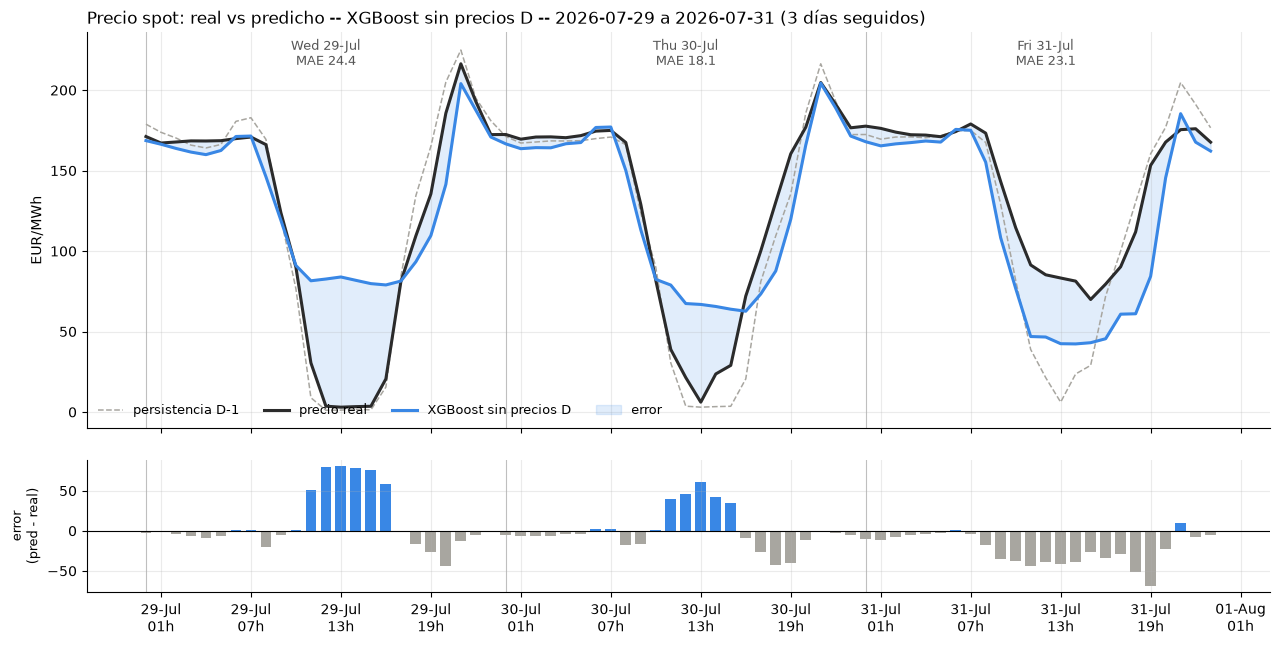

In [11]:
METRICAS_SIN = metricas_diarias(PRED_SIN)
print(METRICAS_SIN.round(2).to_string())
print(f"\nMedia de los {N_DIAS} días -- MAE {METRICAS_SIN['MAE'].mean():.2f} EUR/MWh | "
      f"capturado {100 * METRICAS_SIN['ingreso_EUR'].sum() / METRICAS_SIN['techo_EUR'].sum():.1f}%")

grafico_72h(PRED_SIN, METRICAS_SIN, f"{MODELO} sin precios D", COLOR_SIN,
            sufijo=f"_{MODELO.lower()}_sin_precios_d")

Guardado: C:\Users\Powan\Desktop\Maestria\TFM\edev_models\data_temp\pred_vs_real_paneles_xgboost_sin_precios_d_2026-07-29.png


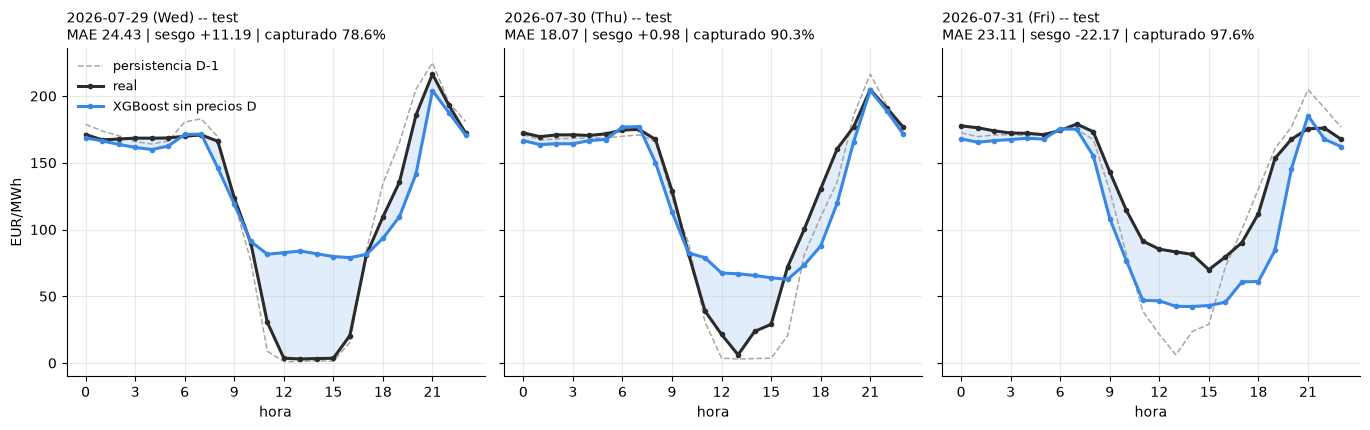

[XGBoost sin precios D]
  Mejor día: 2026-07-30 (MAE 18.07 EUR/MWh)
  Peor día:  2026-07-29 (MAE 24.43 EUR/MWh, fallo máximo 80.9 en la hora 13)
  Sesgo medio: -3.34 EUR/MWh -- predice por debajo del precio real.
  Arbitraje 4h: 1286.2 EUR de un techo de 1484.0 EUR (86.7%).


In [12]:
grafico_paneles(PRED_SIN, METRICAS_SIN, f"{MODELO} sin precios D", COLOR_SIN,
                sufijo=f"_{MODELO.lower()}_sin_precios_d")
resumen_texto(METRICAS_SIN, f"{MODELO} sin precios D")

### Las dos variantes en el mismo eje

Curva real con las dos predicciones superpuestas. Si las líneas naranja y azul se pisan, esas
nueve columnas aportaban poco en estos días; si la azul se despega en los picos, ahí es donde
el precio de los mercados vecinos estaba haciendo el trabajo.


Guardado: C:\Users\Powan\Desktop\Maestria\TFM\edev_models\data_temp\pred_vs_real_comparativa_xgboost_2026-07-29.png


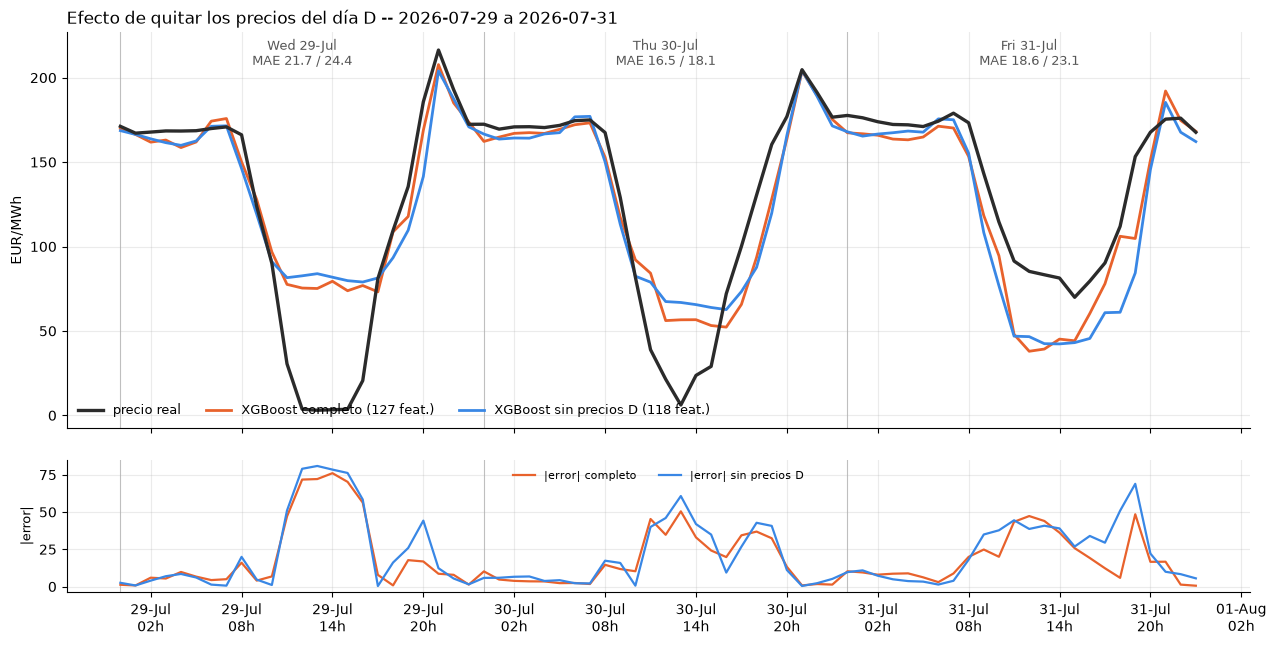

In [ ]:
real_h = a_serie_horaria(P, DIAS, "real")
h_completo = a_serie_horaria(PRED, DIAS, "completo")
h_sin = a_serie_horaria(PRED_SIN, DIAS, "sin precios D")

fig, (ax, axe) = plt.subplots(
    2, 1, figsize=(13, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12})

ax.plot(real_h.index, real_h.values, color=COLOR_REAL, lw=2.4, label="precio real", zorder=4,)
ax.plot(h_completo.index, h_completo.values, color=COLOR_PRED, lw=2.0,
        label=f"{MODELO} completo ({len(feature_cols)} feat.)", zorder=3)
ax.plot(h_sin.index, h_sin.values, color=COLOR_SIN, lw=2.0, ls="-",
        label=f"{MODELO} sin precios D ({len(feature_cols_sin)} feat.)", zorder=3)

for d in DIAS:
    ax.axvline(d, color="grey", lw=0.8, alpha=0.5, zorder=1)
    axe.axvline(d, color="grey", lw=0.8, alpha=0.5, zorder=1)
    f1 = METRICAS.loc[d.strftime("%Y-%m-%d"), "MAE"]
    f2 = METRICAS_SIN.loc[d.strftime("%Y-%m-%d"), "MAE"]
    ax.annotate(f"{d.strftime('%a %d-%b')}\nMAE {f1:.1f} / {f2:.1f}",
                xy=(d + pd.Timedelta(hours=12), ax.get_ylim()[1]),
                xytext=(0, -4), textcoords="offset points",
                ha="center", va="top", fontsize=9, color="#555")

ax.set_ylabel("EUR/MWh")
ax.set_title(f"Efecto de quitar los precios del día D -- {DIAS[0].date()} a {DIAS[-1].date()}",
             loc="left", fontsize=12)
ax.legend(frameon=False, fontsize=9, ncols=3, loc="lower left")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

axe.plot(real_h.index, (h_completo - real_h).abs().values, color=COLOR_PRED, lw=1.6,
         label="|error| completo")
axe.plot(real_h.index, (h_sin - real_h).abs().values, color=COLOR_SIN, lw=1.6,
         label="|error| sin precios D")
axe.set_ylabel("|error|", fontsize=9)
axe.legend(frameon=False, fontsize=8, ncols=2)
axe.grid(alpha=0.25)
axe.spines[["top", "right"]].set_visible(False)
axe.xaxis.set_major_locator(mdates.HourLocator(interval=6))
axe.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b\n%Hh"))

fig.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.12)
if GUARDAR_PNG:
    salida = TEMP / f"pred_vs_real_comparativa_{MODELO.lower()}_{DIAS[0].date()}.png"
    plt.savefig(salida, dpi=150, facecolor="white")
    print("Guardado:", salida)
plt.show()

### Tabla final día a día

In [14]:
TABLA = pd.concat(
    {"completo": METRICAS[["MAE", "RMSE", "sesgo", "capturado_%"]],
     "sin precios D": METRICAS_SIN[["MAE", "RMSE", "sesgo", "capturado_%"]]},
    axis=1)
TABLA[("delta", "MAE")] = METRICAS_SIN["MAE"] - METRICAS["MAE"]
TABLA[("delta", "capturado_%")] = METRICAS_SIN["capturado_%"] - METRICAS["capturado_%"]

print(TABLA.round(2).to_string())
print(f"\nMAE medio de los {N_DIAS} días -- completo {METRICAS['MAE'].mean():.2f} | "
      f"sin precios D {METRICAS_SIN['MAE'].mean():.2f} "
      f"({METRICAS_SIN['MAE'].mean() - METRICAS['MAE'].mean():+.2f} EUR/MWh)")

if GUARDAR_PNG:
    salida_csv = TEMP / f"comparativa_3dias_{MODELO.lower()}_{DIAS[0].date()}.csv"
    TABLA.to_csv(salida_csv)
    print("Guardado:", salida_csv)

TABLA.round(2)

           completo                           sin precios D                           delta            
                MAE   RMSE  sesgo capturado_%           MAE   RMSE  sesgo capturado_%   MAE capturado_%
dia                                                                                                    
2026-07-29    21.69  34.05  12.89       85.54         24.43  37.88  11.19       78.58  2.73       -6.96
2026-07-30    16.55  22.63  -0.05       91.01         18.07  25.48   0.98       90.29  1.52       -0.72
2026-07-31    18.57  23.67 -17.13       96.77         23.11  29.39 -22.17       97.60  4.54        0.84

MAE medio de los 3 días -- completo 18.94 | sin precios D 21.87 (+2.93 EUR/MWh)
Guardado: C:\Users\Powan\Desktop\Maestria\TFM\edev_models\data_temp\comparativa_3dias_xgboost_2026-07-29.csv


completo                           sin precios D                           delta            
                MAE   RMSE  sesgo capturado_%           MAE   RMSE  sesgo capturado_%   MAE capturado_%
dia                                                                                                    
2026-07-29    21.69  34.05  12.89       85.54         24.43  37.88  11.19       78.58  2.73       -6.96
2026-07-30    16.55  22.63  -0.05       91.01         18.07  25.48   0.98       90.29  1.52       -0.72
2026-07-31    18.57  23.67 -17.13       96.77         23.11  29.39 -22.17       97.60  4.54        0.84

In [17]:
SOSPECHOSAS = [c for c in feature_cols
               if c.endswith("_D") or c.startswith(("pdbc_", "pbfli_", "bil_"))]

g = gain(modelo_sin, feature_cols)
print(g.head(10).round(2).to_string())
print("\n-- columnas del lado prohibido de las 11:00 --")
print(g[g.index.isin(SOSPECHOSAS)].head(10).round(2).to_string())
print(f"\nganancia total en columnas _D: {g[g.index.isin(SOSPECHOSAS)].sum():.1f} %")

es_esios_Dm1           27.70
es_esios_Dm6           14.90
gas_mibgas              7.50
capinst_coal_mw         5.52
pdbc_cogen_mw_D         3.26
gas_ttf_m1              2.77
ree_gwind_prev          2.31
pdbc_ccgt_mw_D          2.05
ree_grenov_prev         1.90
d1_regimen_tope_gas     1.45

-- columnas del lado prohibido de las 11:00 --
pdbc_cogen_mw_D                3.26
pdbc_ccgt_mw_D                 2.05
pdbc_pumping_cons_mw_D         1.44
bil_generic_sales_mw_D         0.84
bil_retail_free_buy_mw_D       0.48
pdbc_hydro_ugh_mw_D            0.45
pdbc_unavailable_power_mw_D    0.45
pdbc_biogas_mw_D               0.36
pdbc_other_renew_mw_D          0.32
pdbc_coal_mw_D                 0.31

ganancia total en columnas _D: 12.7 %


In [18]:
for s, sub in df.groupby("split"):
    print(s, sub[["es_esios_D","pt_entsoe_D"]].corrwith(sub["target_price"]).round(4).to_dict())

test {'es_esios_D': 0.8853, 'pt_entsoe_D': 0.8825}
train {'es_esios_D': 0.9166, 'pt_entsoe_D': 0.9178}
validation {'es_esios_D': 0.8165, 'pt_entsoe_D': 0.8089}
